In [9]:
import argparse
import os
import time

import PIL
from PIL import Image

import numpy as np
import torchvision
import pickle
import math

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.autograd import Variable

from sklearn.svm import LinearSVC

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Partie 1 : Architecture VGG16

In [4]:
os.makedirs("data", exist_ok=True)

if os.name == 'nt': # for windows
    !curl -L -o data/imagenet_classes.pkl https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl
    !curl -L -o data/cat.jpg "https://unsplash.com/photos/gKXKBY-C-Dk/download?force=true"
    !curl -L -o data/dog.jpg "https://unsplash.com/photos/qO-PIF84Vxg/download?force=true"

else: # not windows
    !wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl -O data/imagenet_classes.pkl

    # Bonus : Classifiez des exemples avec vgg16 et commentez le résultat dans votre rapport.
    !wget --content-disposition https://unsplash.com/photos/gKXKBY-C-Dk/download?force=true -O data/cat.jpg
    !wget --content-disposition https://unsplash.com/photos/qO-PIF84Vxg/download?force=true -O data/dog.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

 31 35454   31 11024    0     0  24665      0  0:00:01 --:--:--  0:00:01 24665
100 35454  100 35454    0     0  78765      0 --:--:-- --:--:-- --:--:-- 7952k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100 1970k  100 1970k    0     0  3873k      0 --:--:-- --:--:-- --:--:-- 3873k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..1.7162529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.3785625].


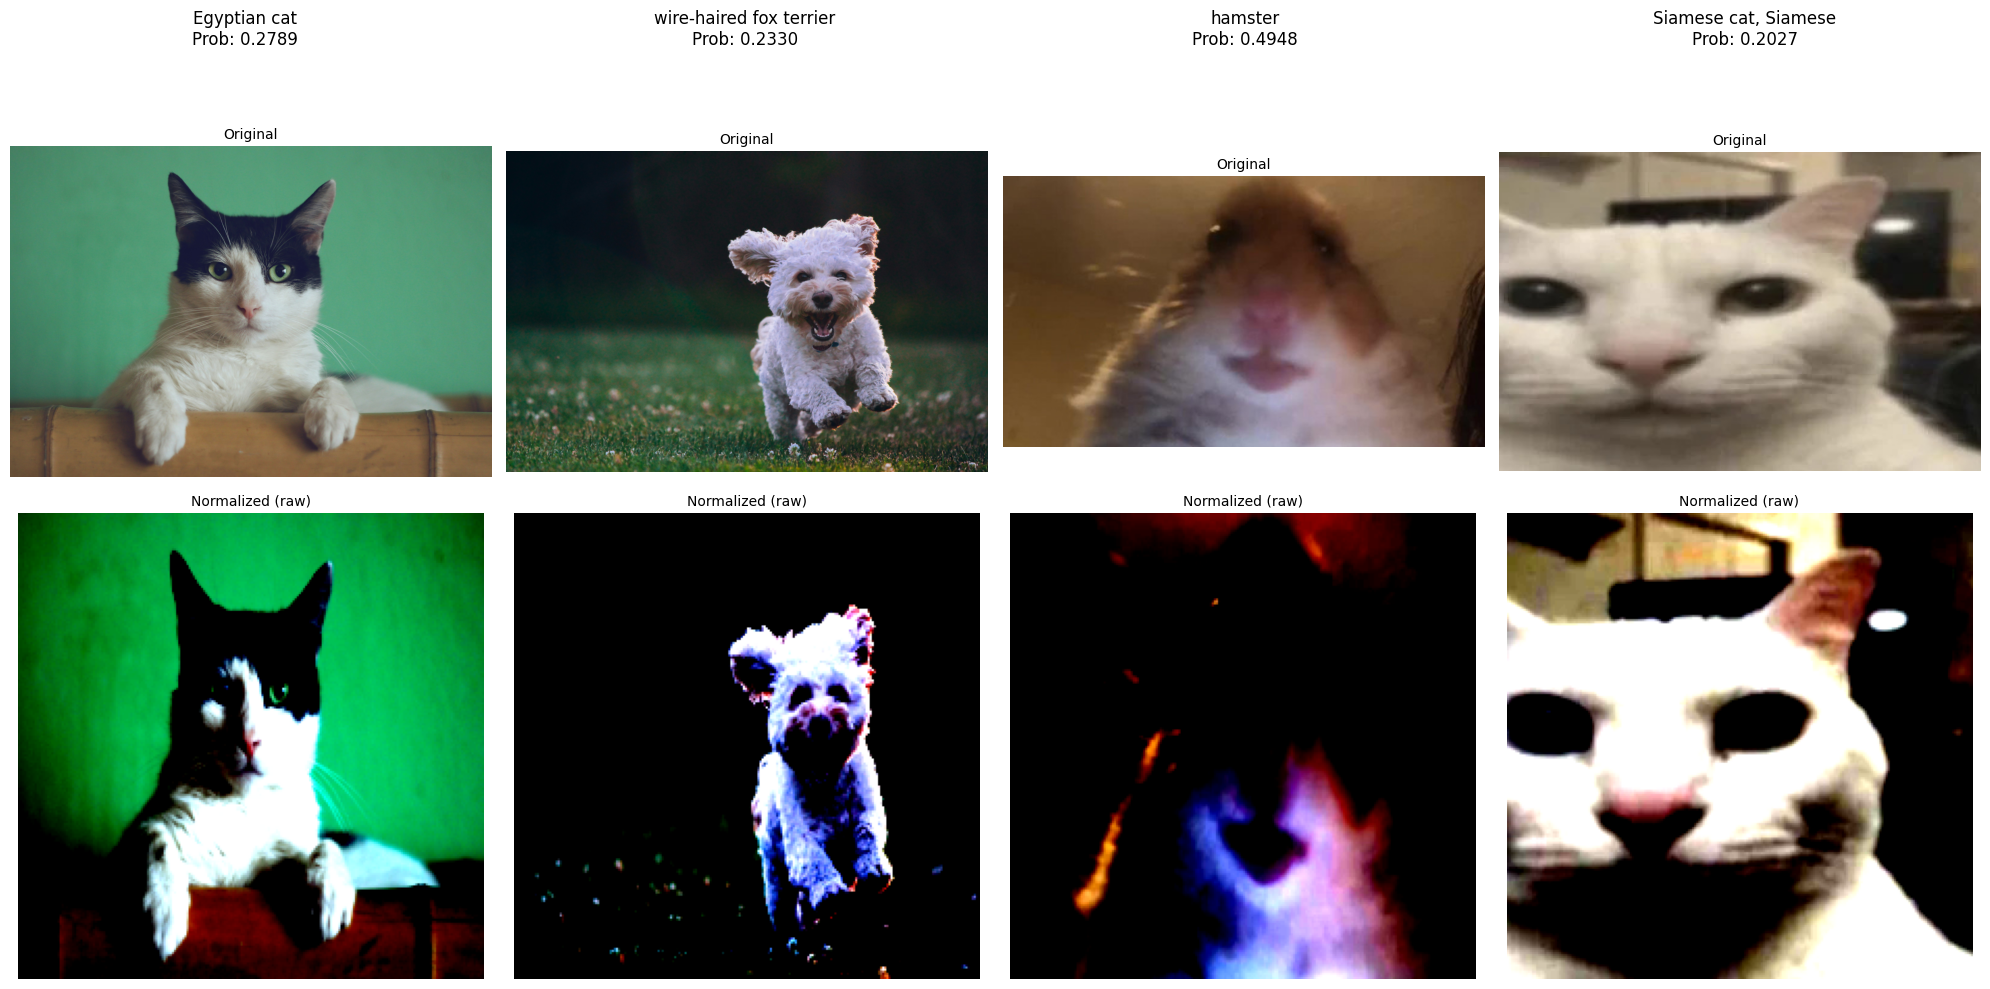

In [5]:
#cat = Image.open('cat.jpg')
cat_img = Image.open('data/cat.jpg')
dog_img = Image.open('data/dog.jpg')
hamster_img = Image.open('data/hamster.jpg')
cat2_img = Image.open('data/cat2.jpg')

# Loading ImageNet classes
imagenet_classes = pickle.load(open('data/imagenet_classes.pkl', 'rb'))

def normalize_image(img):
    # Normalization
    img = img.resize((224, 224), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255
    img = img.transpose((2, 0, 1))
    # ImageNet mean/std
    mu = torch.Tensor([0.485, 0.456, 0.406])
    sigma = torch.Tensor([0.229, 0.224, 0.225])
    # Expand mu & sigma to match image size

    mu = mu[:, None, None]
    sigma = sigma[:, None, None] 
    # now its of size (3, 1, 1)

    # compute the normalized image with mean ImageNet image
    img = (torch.Tensor(img) - mu) / sigma

    return img

def predict_label(img, model, classes_list):
    # Forward pass on VGG
    img = np.expand_dims(img, 0)
    x = torch.Tensor(img)
    y = model(x)
    y = y.detach().numpy() # transformation en array numpy

    prob = torch.softmax(torch.tensor(y), dim=1).numpy()
    # Get prediction (i.e., ImageNet class label)
    pred_id = np.argmax(y)
    pred_label = classes_list[pred_id]
    pred_prob = prob[0, pred_id]
    return pred_prob, pred_id, pred_label

def multiplot_images_with_predictions(images, model, classes_list):
    n = len(images)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 10))  # 2 rows: original + normalized
    for i, img in enumerate(images):
        norm_img = normalize_image(img)
        pred_prob, pred_id, pred_label = predict_label(norm_img, model, classes_list)
        title_text = f"{pred_label}\nProb: {pred_prob:.4f}"

        fig.text((i + 0.5)/n, 0.95, title_text, ha='center', fontsize=12)
        # og image
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        axes[0, i].set_title("Original", fontsize=10)

        # normalized image
        norm_img_display = norm_img.permute(1, 2, 0).numpy()
        axes[1, i].imshow(norm_img_display)
        axes[1, i].axis('off')
        axes[1, i].set_title("Normalized (raw)", fontsize=10)

        

    plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for fig.text at top
    plt.show()
    

# Loding pre-trained VGG
# we are not using vgg16 = torchvision.models.vgg16(pretrained=True)
# because it is deprecated (and i we dont want to see the warning signals)
vgg16 = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1) # only version available i think
vgg16.eval() # WHY THAT ? bc we are not trying to train the model (inference only)

images = [cat_img, dog_img, hamster_img, cat2_img]

multiplot_images_with_predictions(images, vgg16, imagenet_classes)

Bonus question on activation maps:

In [ ]:

def get_layer_activation(model, image):
    x = image.unsqueeze(0)  # add batch dimension
    with torch.no_grad():
        activation_map = model.features[0](x)  # first layer
    return activation_map.squeeze(0)  # remove batch dimension

def plot_activation_maps(activation, nmaps=None):
    n_maps = activation.size(0) if nmaps is None else nmaps # to avoid printing all of them if specified
    n_cols = 8 # 8 images per col
    n_rows = math.ceil(n_maps / n_cols)

    # plot maps
    plt.figure(figsize=(n_cols*2, n_rows*2))
    for i in range(n_maps):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(activation[i].numpy(), cmap='viridis')
        plt.axis('off')
        plt.title(f'{i+1}', fontsize=8)
    plt.suptitle("First conv layer activations", fontsize=14)
    plt.tight_layout()
    plt.show()

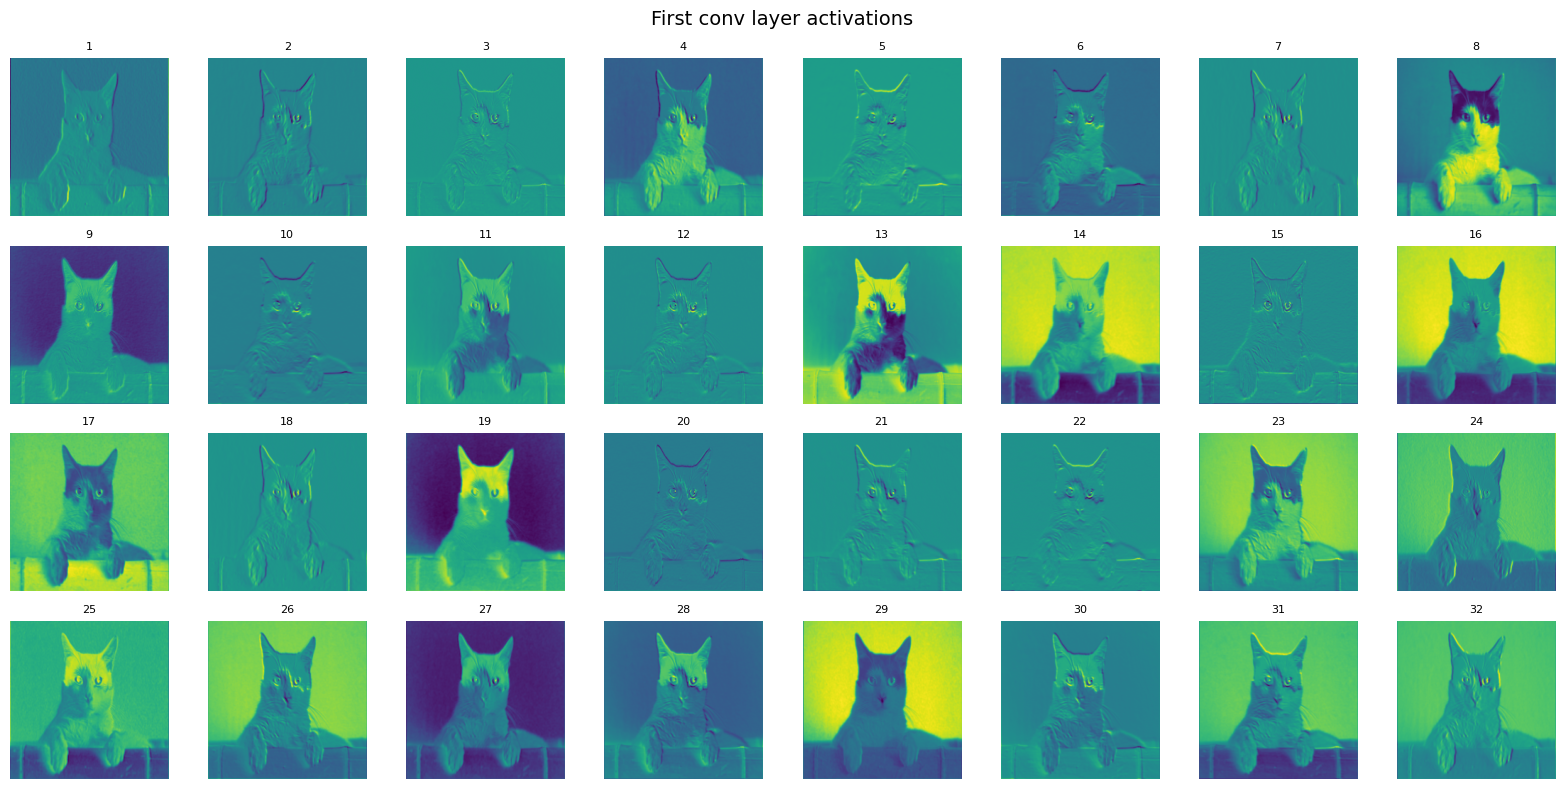

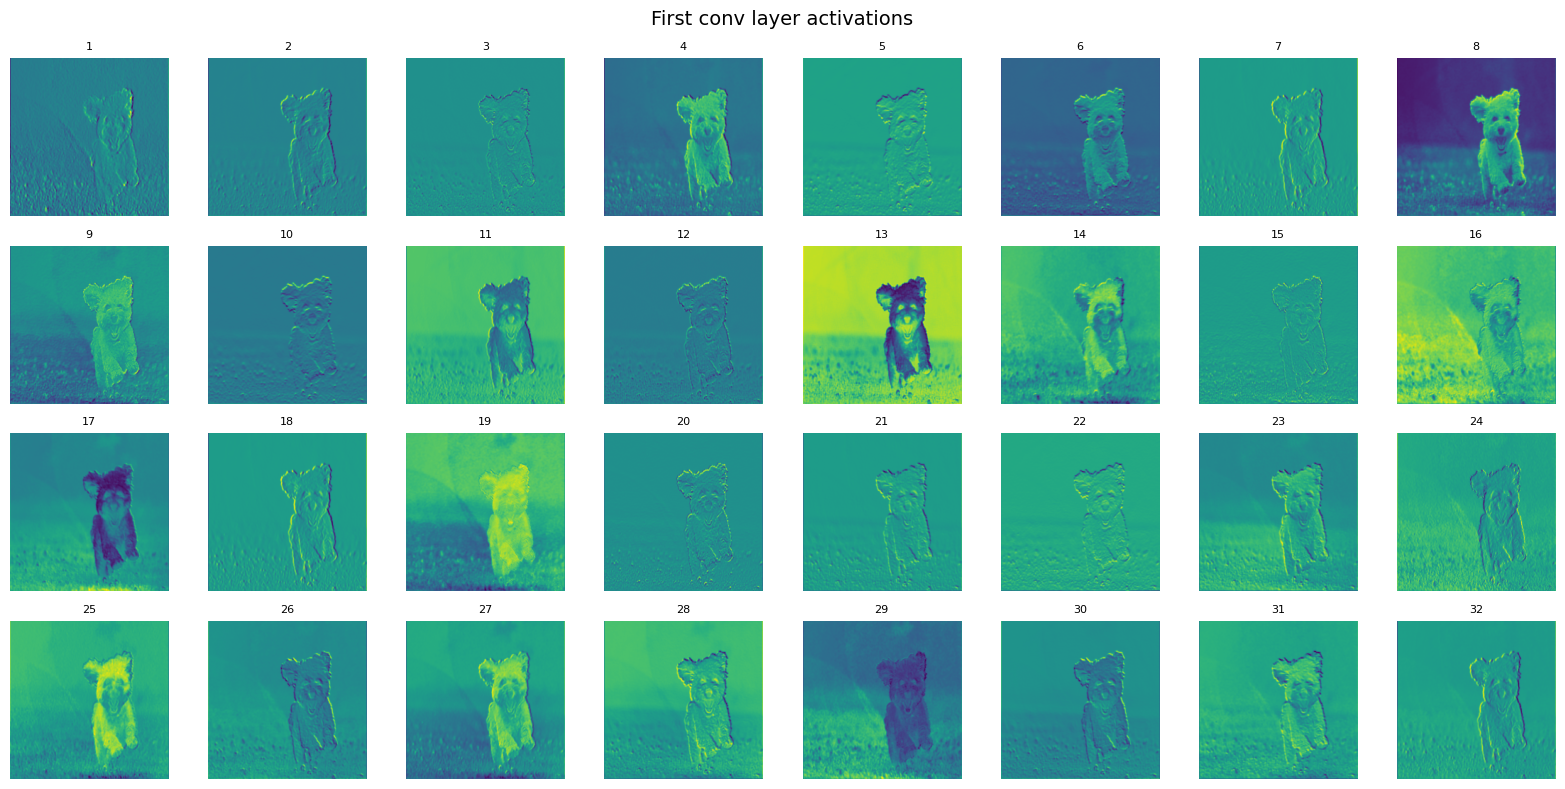

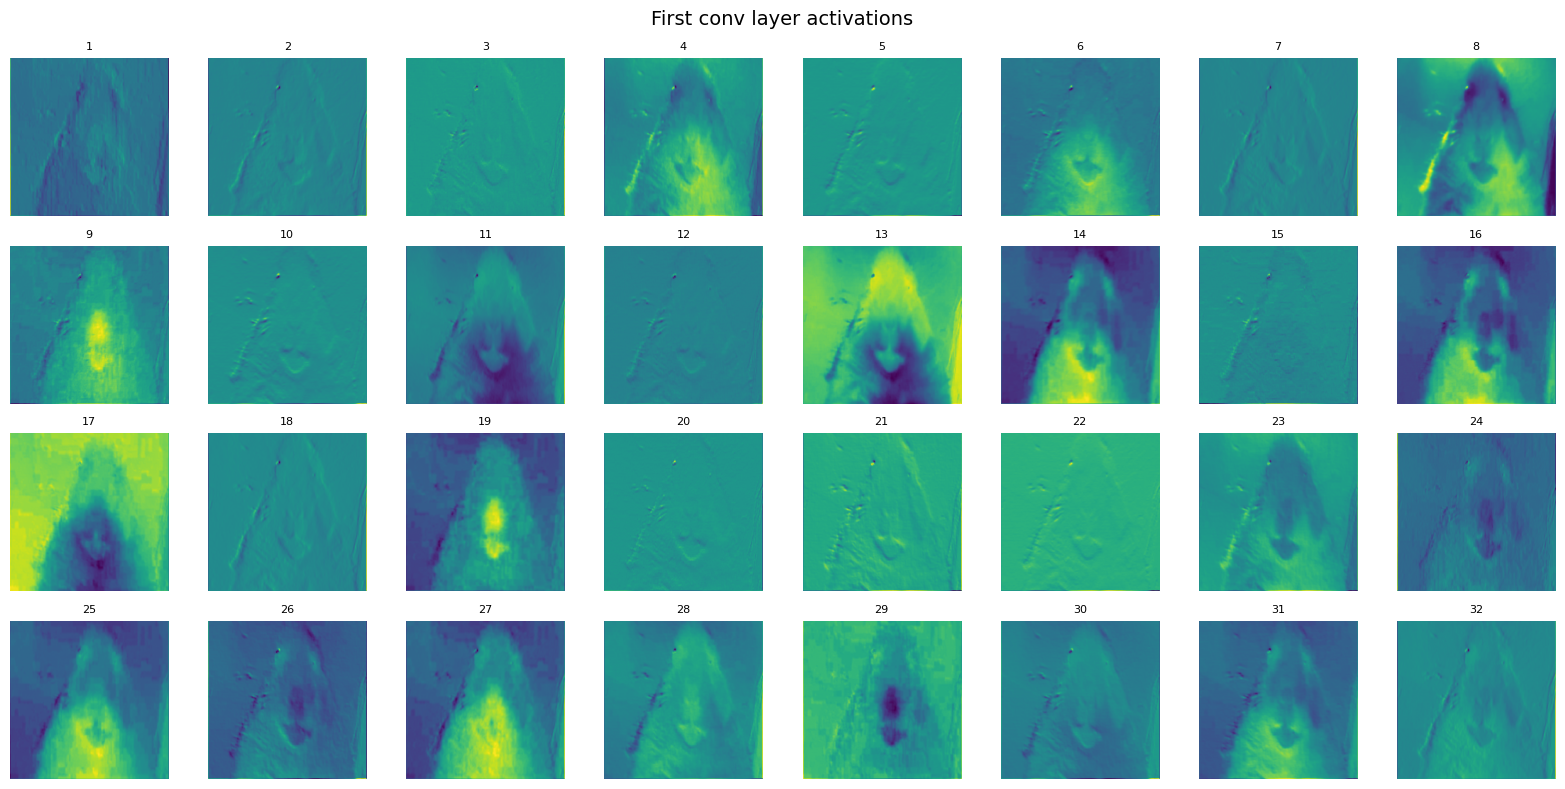

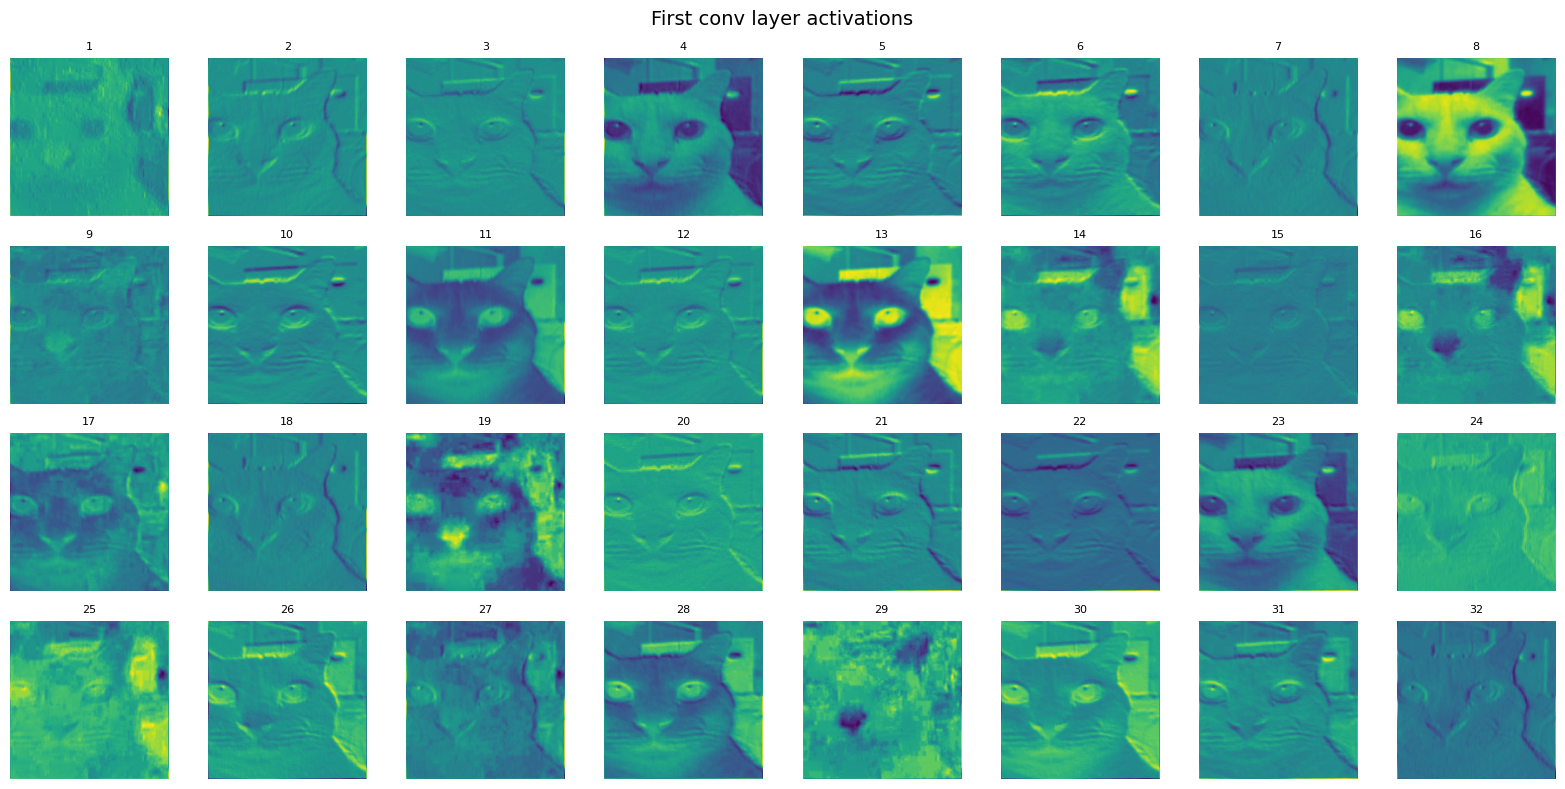

In [15]:
for img in images:
    norm_img = normalize_image(img)
    act = get_layer_activation(vgg16, norm_img)
    plot_activation_maps(act, nmaps=32)

# Partie 2: Transfer Learning avec VGG16 sur 15 Scene

In [ ]:
#!wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/15ScenesData.zip
!wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip

!unzip 15ScenesData.zip

In [ ]:
ls 15SceneData/test/bedroom/

In [ ]:
class VGG16relu17:
  pass  # A COMPLÉTER

In [ ]:

PRINT_INTERVAL = 50
CUDA = True

def get_dataset(batch_size, path):

    # This function expands 3 times a gray level image
    # to transform it into an image RGB. Use it with transform.Lambda
    def duplicateChannel(img):
        img = img.convert('L')
        np_img = np.array(img, dtype=np.uint8)
        np_img = np.dstack([np_img, np_img, np_img])
        img = Image.fromarray(np_img, 'RGB')
        return img
    def resizeImage(img):
      return img.resize((224,224), Image.BILINEAR)

    #####################
    ## YOUR CODE HERE  ##
    #####################
    # Add pre-processing
    train_dataset = datasets.ImageFolder(path+'/train',
        transform=transforms.Compose([ # Pre-processing TODO: duplicateChannel(), resizeImage(), toTensor(), Normalize ()
            transforms.ToTensor()
        ]))
    val_dataset = datasets.ImageFolder(path+'/test',
        transform=transforms.Compose([ # Pre-processing TODO
            transforms.ToTensor()
        ]))
    ####################
    ##      END        #
    ####################

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=CUDA, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=CUDA, num_workers=2)

    return train_loader, val_loader

In [ ]:
def extract_features(data, model):
    #####################
    ## YOUR CODE HERE  ##
    #####################
    # init features matrices
    X = None
    y = None
    ####################
    ##      END        #
    ####################

    for i, (input, target) in enumerate(data):
        if i % PRINT_INTERVAL == 0:
            print('Batch {0:03d}/{1:03d}'.format(i, len(data)))
        if CUDA:
            input = input.cuda()
        #####################
        ## YOUR CODE HERE  ##
        #####################

        ####################
        ##      END        #
        ####################

    return X, y


def main(path="15SceneData", batch_size=8):
    print('Instanciation de VGG16')
    vgg16 = models.vgg16(pretrained=True)

    print('Instanciation de VGG16relu7')
    #####################
    ## YOUR CODE HERE  ##
    #####################
    # Remplacer par le modèle par un réseau tronqué pour faire de la feature extraction
    # On créera une nouvelle classe VGG16relu7 ici
    model = vgg16
    ####################
    ##      END        #
    ####################

    model.eval()
    if CUDA: # si on fait du GPU, passage en CUDA
        cudnn.benchmark = True
        model = model.cuda()

    # On récupère les données
    print('Récupération des données')
    train, test = get_dataset(batch_size, path)

    # Extraction des features
    print('Feature extraction')
    X_train, y_train = extract_features(train, model)
    X_test, y_test = extract_features(test, model)

    #####################
    ## Votre code ici  ##
    #####################
    # Apprentissage et évaluation des SVM à faire
    print('Apprentissage des SVM')
    accuracy = 0
    ####################
    ##      FIN        #
    ####################
    print('Accuracy = %f' % accuracy)


In [ ]:
main("15SceneData", 8)